## Problem Statement
*To create a classification model to predict weather the bank client will subscribe to a term deposit(Yes/No) based on their demographic, financial, and previous contact information, so that marketing team can target the most promising clients and reduce the number of unsuccessful calls.*

| Name        | Role    | Type        | Units | Description                                                                                                                                                                                                                                                                                                                                                                                                        | Missing Values |
| ----------- | ------- | ----------- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------- |
| age         | feature | integer     |       |                                                                                                                                                                                                                                                                                                                                                                                                                    | No             |
| job         | feature | categorical |       | type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')                                                                                                                                                                                                                                       | No             |
| marital     | feature | categorical |       | marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)                                                                                                                                                                                                                                                                                                  | No             |
| education   | feature | categorical |       | (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')                                                                                                                                                                                                                                                                                     | No             |
| default     | feature | binary      |       | has credit in default?                                                                                                                                                                                                                                                                                                                                                                                             | No             |
| balance     | feature | integer     | euros | average yearly balance                                                                                                                                                                                                                                                                                                                                                                                             | No             |
| housing     | feature | binary      |       | has housing loan?                                                                                                                                                                                                                                                                                                                                                                                                  | No             |
| loan        | feature | binary      |       | has personal loan?                                                                                                                                                                                                                                                                                                                                                                                                 | No             |
| contact     | feature | categorical |       | contact communication type (categorical: 'cellular','telephone')                                                                                                                                                                                                                                                                                                                                                   | Yes            |
| day | feature | date        |       | last contact day of the week                                                                                                                                                                                                                                                                                                                                                                                       | No             |
| month       | feature | date        |       | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')                                                                                                                                                                                                                                                                                                                                   | No             |
| duration    | feature | integer     |       | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. | No             |
| campaign    | feature | integer     |       | number of contacts performed during this campaign and for this client (numeric, includes last contact)                                                                                                                                                                                                                                                                                                             | No             |
| pdays       | feature | integer     |       | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)                                                                                                                                                                                                                                                                 | Yes            |
| previous    | feature | integer     |       | number of contacts performed before this campaign and for this client                                                                                                                                                                                                                                                                                                                                              | No             |
| poutcome    | feature | categorical |       | outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')                                                                                                                                                                                                                                                                                                                        | Yes            |
| y           | target  | binary      |       | has the client subscribed a term deposit?                                                                                                                                                                                                                                                                                                                                                                          | No             |

## Load The dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, roc_auc_score

# --- Models ---
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier

# --- SMOTE ---
from imblearn.over_sampling import SMOTE

ACCENT  = "#38bdf8"   # sky-blue
ACCENT2 = "#f472b6"   # pink
ACCENT3 = "#34d399"   # emerald
ACCENT4 = "#fb923c"   # orange
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, "#a78bfa", "#fbbf24"]

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bank Marketing/bank-full.csv', sep=';')
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head()

Dataset shape : 45,211 rows × 17 columns
Memory usage  : 27.00 MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Data Cleaning

In [5]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0].to_string())
print(f"\nTotal missing cells: {missing.sum()}")

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0

Total missing cells: 0


In [6]:
# Encode categorical variables
print("Target class distribution (%):")
print(df["y"].value_counts()/len(df)*100)
print(f"\nImbalance ratio: {df['y'].value_counts()['no'] / df['y'].value_counts()['yes']:.1f} : 1")

Target class distribution (%):
y
no     88.30152
yes    11.69848
Name: count, dtype: float64

Imbalance ratio: 7.5 : 1


**Key decisions:**
- **`unknown` values** in categorical columns are retained as a valid category (they carry signal).
- **`pdays == -1`** means the client was never previously contacted → extract a binary flag, then replace -1 with 0.
- **`default`** column is highly imbalanced (99.8 % `no`) but kept for feature completeness.
- Encode the binary target `y` → `y_binary` (1 = yes, 0 = no).

In [7]:
df['job']=np.where(df['job']=='admin.', 'admin', df['job'])

In [8]:
# Clients previously contacted
prev_contacted = (df["pdays"] != -1)
print(f"Clients previously contacted : {prev_contacted.sum():,}"
      f" ({100 * prev_contacted.mean():.1f} %)")

# Clients NOT previously contacted
print(f"Clients NOT previously contacted: {(df['pdays'] == -1).sum():,}")

# Replace -1 with 0 (after extracting the flag)
df["pdays"] = df["pdays"].replace(-1, 0)

Clients previously contacted : 8,257 (18.3 %)
Clients NOT previously contacted: 36,954


In [44]:
print(f"Shape after cleaning : {df.shape}")
print(f"Null values remaining: {df.isnull().sum().sum()}")
df.head(3)

Shape after cleaning : (45211, 17)
Null values remaining: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,0,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,0,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,0,0,unknown,0


## Outlier Detection
### Strategy (scenario-aware)
| Feature | Decision | Reason |
|---------|----------|--------|
| `balance` | Winsorize (1st–99th pct) | Legitimate negatives (overdrafts) + extreme wealth; cap extremes |
| `duration` | Winsorize (1st–99th pct) | Very long calls are real but extreme values distort distance metrics |
| `campaign` | Winsorize (1st–99th pct) | >30 contacts per campaign is operationally implausible |
| `previous` | Winsorize (1st–99th pct) | Extreme values are encoding errors |
| `pdays` | Winsorize (1st–99th pct) | Days since last contact > 2 years is noise |
| `age` | **No treatment** | Max 95 is a valid senior-citizen age — removing harms elderly segment |

## Train Test Split

In [20]:
X = df_transformed.drop('y', axis=1)
y = df_transformed['y']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")
print(f"\nFeatures ({len(X.columns)}) :")
display(X.info())

Feature matrix X : (45211, 16)
Target vector y  : (45211,)

Features (16) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  int64  
 1   job        45211 non-null  object 
 2   marital    45211 non-null  object 
 3   education  45211 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    45211 non-null  object 
 9   day        45211 non-null  int64  
 10  month      45211 non-null  object 
 11  duration   45211 non-null  float64
 12  campaign   45211 non-null  float64
 13  pdays      45211 non-null  float64
 14  previous   45211 non-null  float64
 15  poutcome   45211 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.5+ MB


None

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set : {len(X_train):,} rows  (0: {(y_train==0).sum():,} | 1: {(y_train==1).sum():,})")
print(f"Test set     : {len(X_test):,} rows  (0: {(y_test==0).sum():,}  | 1: {(y_test==1).sum():,})")
print(f"\nClass ratio in train : {(y_train==0).sum()/(y_train==1).sum():.1f} : 1  (imbalanced)")

Training set : 36,168 rows  (0: 31,937 | 1: 4,231)
Test set     : 9,043 rows  (0: 7,985  | 1: 1,058)

Class ratio in train : 7.5 : 1  (imbalanced)


In [33]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

## Feature Scaling

In [22]:
robust_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']
target_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

preprocessor = ColumnTransformer(
    transformers=[
        ('Scaling',  RobustScaler(),  robust_cols),
        ('Encoding', TargetEncoder(), target_cols),
    ]
)

X_train_trans = preprocessor.fit_transform(X_train, y_train)
X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)

X_test_trans = preprocessor.transform(X_test)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_train.columns)

In [23]:
X_test_trans.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,0.066667,0.139355,0.583249,0.000000,0.0,0.0,-0.615385,0.072928,0.100364,0.086245,0.118043,0.0771,0.068128,0.041116,0.066808,0.092231
1,0.333333,-0.053825,0.106730,0.000000,0.0,0.0,1.076923,0.109263,0.100364,0.106730,0.118043,0.0771,0.126338,0.041116,0.066808,0.092231
2,-0.533333,-0.070046,0.209872,1.000000,0.0,0.0,0.307692,0.089015,0.100364,0.106730,0.118043,0.0771,0.126338,0.041116,0.104086,0.092231
3,-0.200000,0.150415,-0.144133,0.736966,0.0,0.0,0.538462,0.072928,0.100364,0.086245,0.118043,0.0771,0.126338,0.041116,0.066808,0.092231
4,-0.333333,1.083871,-0.955891,-0.584963,0.0,0.0,-0.923077,0.089015,0.150089,0.106730,0.118043,0.0771,0.126338,0.148347,0.167917,0.092231


## Handling Imbalanced Data using SMOTE
**SMOTE** (Synthetic Minority Over-sampling Technique) generates *new synthetic*  
minority-class samples by interpolating between real minority samples and their  
k-nearest neighbours — avoiding simple duplication.

In [24]:
from imblearn.pipeline import Pipeline as ImbPipeline

models = {
    "Decision Tree"     : DecisionTreeClassifier(),
    "Random Forest"     : RandomForestClassifier(n_jobs=-1),
    "Gradient Boosting" : GradientBoostingClassifier(),
}

# Wrap each model in a SMOTE → model pipeline
pipelines = {
    name: ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model)
    ])
    for name, model in models.items()
}

## Hyperparameter Tuning

In [25]:
param_grids = {
    "Decision Tree": {
        "clf__max_depth"        : [5, 10, 15, None],
        "clf__min_samples_leaf" : [1, 5, 10],
        "clf__criterion"        : ["gini", "entropy"],
    },
    "Random Forest": {
        "clf__n_estimators"     : [100, 200],
        "clf__max_depth"        : [10, 20, None],
        "clf__min_samples_leaf" : [1, 5],
    },
    "Gradient Boosting": {
        "clf__n_estimators"  : [100, 200],
        "clf__learning_rate" : [0.05, 0.1, 0.2],
        "clf__max_depth"     : [3, 5],
    },
}

In [27]:
tuned_models  = {}
tuned_results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    print(f"\n  Tuning: {name}", flush=True)

    r_search = RandomizedSearchCV(
        estimator  = pipeline,
        param_distributions = param_grids[name],
        cv         = cv,
        scoring    = "roc_auc",
        n_jobs     = 1,
        verbose    = 1
    )
    r_search.fit(X_train_trans, y_train)

    tuned_models[name]  = r_search.best_estimator_
    tuned_results[name] = {
        "best_params" : r_search.best_params_,
        "best_cv_auc" : r_search.best_score_,
    }
    print(f"    Best params : {r_search.best_params_}")
    print(f"    Best CV AUC : {r_search.best_score_:.4f}")


  Tuning: Decision Tree
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best params : {'clf__min_samples_leaf': 5, 'clf__max_depth': 10, 'clf__criterion': 'entropy'}
    Best CV AUC : 0.8720

  Tuning: Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best params : {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_depth': 20}
    Best CV AUC : 0.9231

  Tuning: Gradient Boosting
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best params : {'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.1}
    Best CV AUC : 0.9282


## Model Training


Decision Tree  Best threshold: 0.55
   Best F1       : 0.5223
   Precision     : 0.4079
   Recall        : 0.7259

Random Forest  Best threshold: 0.80
   Best F1       : 0.5848
   Precision     : 0.5171
   Recall        : 0.6730

Gradient Boosting  Best threshold: 0.99
   Best F1       : 0.5992
   Precision     : 0.5065
   Recall        : 0.7335


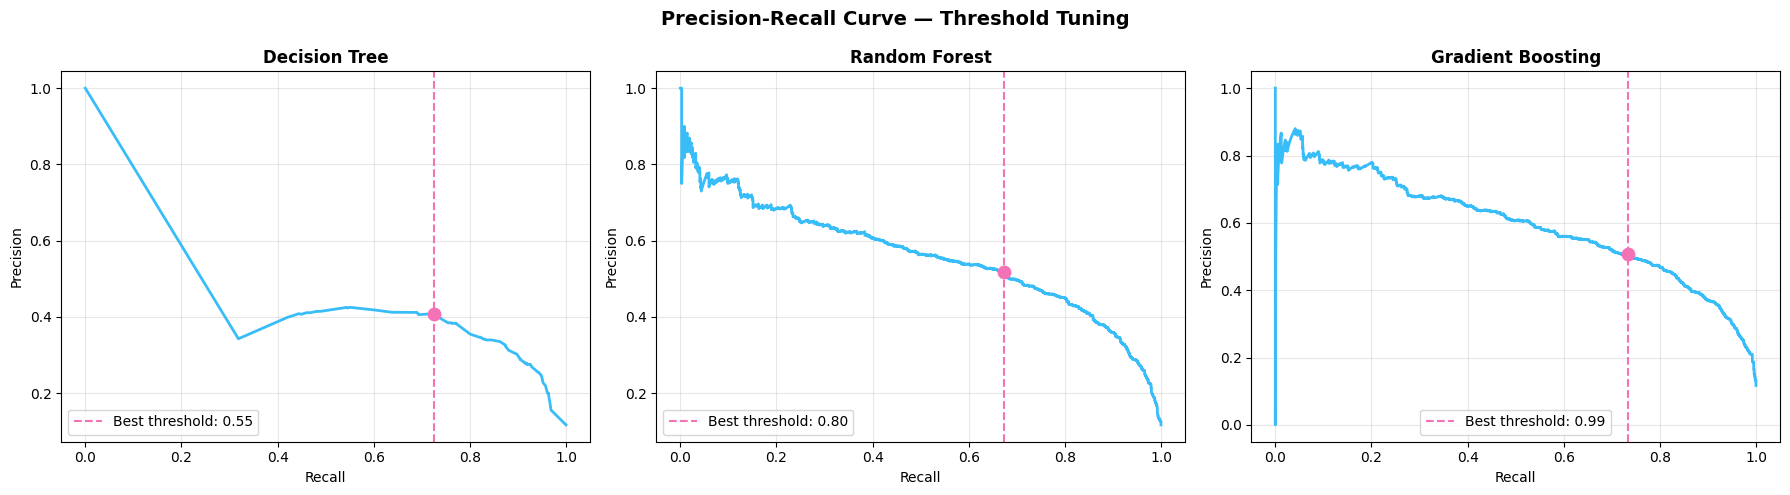

In [34]:
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Precision-Recall Curve — Threshold Tuning", fontsize=14, fontweight="bold")

best_thresholds = {}

for i, (name, pipeline) in enumerate(tuned_models.items()):
    y_prob = pipeline.predict_proba(X_test_trans)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # Find threshold with best F1
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx  = f1_scores.argmax()
    best_thresh = thresholds[best_idx]
    best_thresholds[name] = best_thresh

    axes[i].plot(recalls, precisions, color=ACCENT, linewidth=2)
    axes[i].axvline(recalls[best_idx],    color=ACCENT2, linestyle='--', label=f"Best threshold: {best_thresh:.2f}")
    axes[i].scatter(recalls[best_idx], precisions[best_idx], color=ACCENT2, zorder=5, s=80)
    axes[i].set_title(f"{name}", fontweight="bold")
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

    print(f"\n{name}  Best threshold: {best_thresh:.2f}")
    print(f"   Best F1       : {f1_scores[best_idx]:.4f}")
    print(f"   Precision     : {precisions[best_idx]:.4f}")
    print(f"   Recall        : {recalls[best_idx]:.4f}")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Bank Marketing/precision_recall_curves.png", dpi=300)
plt.tight_layout()
plt.show()

## Evaluation Metrics

In [29]:
print("\n--- Results After Threshold Tuning ---")

for name, pipeline in tuned_models.items():
    y_prob      = pipeline.predict_proba(X_test_trans)[:, 1]
    best_thresh = best_thresholds[name]

    # Apply custom threshold instead of default 0.5
    y_pred_tuned = (y_prob >= best_thresh).astype(int)

    print(f"\n{'='*55}")
    print(f"  {name}  (threshold = {best_thresh:.2f})")
    print(f"{'='*55}")
    print(f"  F1        : {f1_score(y_test, y_pred_tuned):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred_tuned):.4f}")
    print(classification_report(y_test, y_pred_tuned))


--- Results After Threshold Tuning ---

  Decision Tree  (threshold = 0.55)
  F1        : 0.5223
  Recall    : 0.7259
  Precision : 0.4079
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      7985
           1       0.41      0.73      0.52      1058

    accuracy                           0.84      9043
   macro avg       0.68      0.79      0.71      9043
weighted avg       0.89      0.84      0.86      9043


  Random Forest  (threshold = 0.80)
  F1        : 0.5848
  Recall    : 0.6730
  Precision : 0.5171
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      7985
           1       0.52      0.67      0.58      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.79      0.76      9043
weighted avg       0.90      0.89      0.89      9043


  Gradient Boosting  (threshold = 0.99)
  F1        : 0.5992
  Recall    : 0.7335
  Precision : 0.5065
  

In [30]:
from sklearn.metrics import average_precision_score

best_name     = "Gradient Boosting"
best_pipeline = tuned_models[best_name]
best_thresh   = best_thresholds[best_name]

y_prob       = best_pipeline.predict_proba(X_test_trans)[:, 1]
y_pred_final = (y_prob >= best_thresh).astype(int)

print(f"Best Model    : {best_name}")
print(f"Threshold     : {best_thresh:.2f}")
print(f"F1            : {f1_score(y_test, y_pred_final):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

Best Model    : Gradient Boosting
Threshold     : 0.99
F1            : 0.5992
Recall        : 0.7335
Precision     : 0.5065
ROC-AUC       : 0.9202
PR-AUC        : 0.5949

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      7985
           1       0.51      0.73      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.82      0.77      9043
weighted avg       0.91      0.89      0.89      9043



## Pickle Dump

In [31]:
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model'     : best_pipeline,
        'threshold' : best_thresh,
        'name'      : best_name
    }, f)

print("Model saved to best_model.pkl")

Model saved to best_model.pkl


In [32]:
with open('best_model.pkl', 'rb') as f:
    saved = pickle.load(f)

model     = saved['model']
threshold = saved['threshold']

y_prob = model.predict_proba(X_test_trans)[:, 1]
y_pred = (y_prob >= threshold).astype(int)